# Combined Real Fly Trajectory Figure

Plots sample trajectories from **all 10 conditions** on a single Letter-sized page.

| Group | Conditions |
|-------|-----------|
| S3 dataset | Steady laminar (low z), Unsteady laminar (low z), Laminar training, Still-air training |
| Variable wind | 0, 0.03, 0.1, 0.2, 0.3, 0.6 m/s |

**Output:** `combined_real_trajectories.svg` — 8.5 × 11 in, 1 in margins.

**Color code**
- Grey = pre-stimulus (t < 0)
- Red = first `FLASH_END_SEC` seconds after flash onset
- Black + arrowhead = post-stimulus

**Workflow:** edit the *Parameters* cell → Run All.

In [1]:
import os, sys
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.collections import PatchCollection
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec
from pathlib import Path
import pynumdiff

%matplotlib inline
plt.rcParams["figure.dpi"] = 300

## Parameters
Edit the cell below and **Run All** to regenerate the figure.

In [2]:
# ── Layout ───────────────────────────────────────────────────────────────────
N_TRAJ_COLS = 3    # trajectory columns per condition panel
N_TRAJ_ROWS = 3    # trajectory rows per condition panel
N_TRAJS     = N_TRAJ_COLS * N_TRAJ_ROWS   # 6 per condition

# ── Sampling ──────────────────────────────────────────────────────────────────
SEED = 42
# To pin specific trajectories for a condition, add entries like:

# ── Time window ───────────────────────────────────────────────────────────────
MAX_TIME_SEC  = 4   # clip trajectories longer than this (s after flash onset)
FLASH_END_SEC = 0.675   # first N seconds after flash onset shown in red

# ── Line style ────────────────────────────────────────────────────────────────
LW           = 0.5    # trajectory line width
ARROW_LENGTH = 0.04   # arrowhead length (metres)

In [3]:
plt.rcParams["font.family"]     = "sans-serif"
plt.rcParams["font.sans-serif"] = (
    ["Helvetica",] + plt.rcParams["font.sans-serif"]
)
plt.rcParams["text.usetex"] = False
plt.rcParams["font.weight"]  = "normal"

## Plotting helpers

In [4]:
def _mean_angle(angles):
    return np.arctan2(np.mean(np.sin(angles)), np.mean(np.cos(angles)))


def _plot_arrowhead_trajectory(x, y, color="black", arrow_length=0.04,
                               arrow_angle=28, ax=None, linewidth=0.5):
    if len(x) < 2:
        return
    xvel = pynumdiff.finite_difference.second_order(x, 1)[1]
    yvel = pynumdiff.finite_difference.second_order(y, 1)[1]
    last_deg = np.rad2deg(_mean_angle(np.arctan2(yvel, xvel)[-3:]))
    ax.plot(x, y, color=color, linewidth=linewidth)
    # Tip placed slightly ahead of last point; wedge opens backward so tip points forward
    cx = x[-1] + np.cos(np.deg2rad(last_deg)) * arrow_length * 0.25
    cy = y[-1] + np.sin(np.deg2rad(last_deg)) * arrow_length * 0.25
    theta1 = last_deg + 180 - arrow_angle / 2
    theta2 = last_deg + 180 + arrow_angle / 2
    wedge = mpatches.Wedge((cx, cy), arrow_length, theta1, theta2)
    ax.add_collection(PatchCollection([wedge], facecolors=color, edgecolors="none"))


def plot_trajectory(df, traj_id, ax, xlim, ylim,
                    flash_end_sec=0.5, max_time_sec=4.5,
                    lw=0.5, arrow_length=0.04, scale_bar=False):
    """Plot one trajectory.

    DataFrame must have columns: obj_id_unique, frame, t_sec, x, y.
    Rows are sorted by 'frame' (the authoritative chronological order).
    Trajectories longer than max_time_sec are clipped.
    """
    t = (df[df["obj_id_unique"] == traj_id]
         .sort_values("frame")
         .loc[lambda d: d["t_sec"] <= max_time_sec])

    pre  = t[t["t_sec"] < 0]
    dur  = t[(t["t_sec"] >= 0) & (t["t_sec"] <= flash_end_sec)]
    post = t[t["t_sec"] > flash_end_sec]

    if len(post) >= 2:
        _plot_arrowhead_trajectory(post["x"].values, post["y"].values,
                                   color="black", ax=ax, linewidth=lw,
                                   arrow_length=arrow_length)
    if len(pre) >= 2:
        ax.plot(pre["x"], pre["y"], color="grey", alpha=0.8, linewidth=lw)
    if len(dur) >= 2:
        ax.plot(dur["x"], dur["y"], color="r", linewidth=lw)

    ax.axis("off")
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.set_aspect("equal")

    if scale_bar:
        x0, x1 = xlim
        y0, y1 = ylim
        x_range  = x1 - x0
        bar_size = 0.05
        for cand in [0.1, 0.2]:
            if cand <= 0.25 * x_range:
                bar_size = cand
        bar_x_end   = x1 - 0.05 * x_range
        bar_x_start = bar_x_end - bar_size
        bar_y       = y0 + 0.08 * (y1 - y0)
        ax.plot([bar_x_start, bar_x_end], [bar_y, bar_y],
                color="k", linewidth=1.5, solid_capstyle="butt")
        ax.text((bar_x_start + bar_x_end) / 2, bar_y - 0.03 * (y1 - y0),
                f"{int(bar_size * 100)} cm",
                ha="center", va="top", fontsize=5.5, color="k")

## Load data

In [5]:
# Notebook is expected to be run from its own directory.
NB_DIR   = Path.cwd()
HDF_DIR  = (NB_DIR / "../../../Data/Experimental_Fly_Data").resolve()

assert HDF_DIR.exists(), (
    f"Data directory not found:\n{HDF_DIR}\n"
    "Please open a terminal in this notebook's folder and launch Jupyter from there."
)
print(f"Data directory: {HDF_DIR}")

AssertionError: Data directory not found:
/Users/jaleesahoule/Desktop/SPLITFLOW/final_split_flow_gitrepo/SplitFlowOptoTracking_new/Data/Experimental_Fly_Data
Please open a terminal in this notebook's folder and launch Jupyter from there.

In [74]:
# ── Variablewind parquet ──────────────────────────────────────────────────────
vw_df = pd.read_parquet(HDF_DIR / "flies_varwind_C1WT_combined_optotrigger_fancontrol_trimmed.parquet")
vw_df = vw_df.sort_values(["obj_id_unique", "frame"]).reset_index(drop=True)
vw_df = vw_df.dropna(subset=["fan_speed_percent"])

# Confirmed flash: experiment log AND sensor must agree
vw_df = vw_df.groupby("obj_id_unique").filter(
    lambda d: (d["duration_of_flash"] > 0).any() and (d["lights_on"] == 255.0).any()
)
vw_df["t_sec"] = vw_df["time_relative_to_flash"]   # already in seconds
vw_df["ground speed"] = np.sqrt(vw_df["xvel"]**2 + vw_df["yvel"]**2)

print(f"Variablewind: {vw_df['obj_id_unique'].nunique()} confirmed-flash trajectories")

Variablewind: 3249 confirmed-flash trajectories


In [75]:
def _load_hdf(filename, flash_only=True, z_max=None):
    """Load an HDF trajectory file, sort chronologically, and add t_sec (seconds)."""
    df = pd.read_hdf(HDF_DIR / filename)
    df = df.sort_values(["obj_id_unique", "frame"]).reset_index(drop=True)
    df["t_sec"] = df["time stamp"] / 1000.0

    # Derive ground speed if absent
    if "ground speed" not in df.columns and {"xvel", "yvel"}.issubset(df.columns):
        df["ground speed"] = np.sqrt(df["xvel"] ** 2 + df["yvel"] ** 2)

    if flash_only:
        # duration > 0  →  a real flash was delivered (not a sham trial)
        df = df.groupby("obj_id_unique").filter(lambda d: (d["duration"] > 0).any())

    if z_max is not None:
        df = df.groupby("obj_id_unique").filter(lambda d: d["z"].max() < z_max)

    return df


# S3 conditions  (low-altitude = z < 0.25 m)
bottom_lam_df = _load_hdf(
    "all_nights_new_processing_protocol_bottom_laminar_09092024.hdf",
    flash_only=True, z_max=0.25,
)
top_lam_df = _load_hdf(
    "all_nights_new_processing_protocol_top_laminar_09082024.hdf",
    flash_only=True, z_max=0.25,
)
# Training datasets are all-flash (duration never 0), so skip flash_only filter
train_lam_df = _load_hdf("training_laminar_df.hdf",  flash_only=False)
train_sa_df  = _load_hdf("training_stillair_df.hdf", flash_only=False)

print(f"Bottom laminar : {bottom_lam_df['obj_id_unique'].nunique()}")
print(f"Top laminar    : {top_lam_df['obj_id_unique'].nunique()}")
print(f"Train laminar  : {train_lam_df['obj_id_unique'].nunique()}")
print(f"Train still air: {train_sa_df['obj_id_unique'].nunique()}")

Bottom laminar : 247
Top laminar    : 213
Train laminar  : 312
Train still air: 251


## Define conditions

`conditions` is the ordered list that drives the figure.  Add, remove, or reorder entries here.

Each entry:
| key | meaning |
|-----|---------|
| `"label"` | panel title |
| `"df"` | pre-loaded DataFrame (must have `t_sec`, `x`, `y`, `frame`, `obj_id_unique`) |
| `"min_gs"` | optional minimum *mean* ground speed (m/s) used when selecting trajectories |

In [125]:
conditions = [
    # ── S3 conditions ──────────────────────────────────────────────────────
    {"label": "Steady flow (z<0.25m)",   "df": bottom_lam_df, "min_gs": 0.15},
    {"label": "Unsteady flow (z<0.25m)", "df": top_lam_df,    "min_gs": 0.15},
    {"label": "Laminar flow (0.4 m/s)",      "df": train_lam_df,  "min_gs":0.15},
    {"label": "Still air",    "df": train_sa_df,   "min_gs": 0.15},
    # ── Variable-wind conditions ───────────────────────────────────────────
    {"label": "0 m/s",    "df": vw_df[vw_df.fan_speed_percent == 12.0], "min_gs": 0.15},
    {"label": "0.03 m/s", "df": vw_df[vw_df.fan_speed_percent == 20.0], "min_gs": 0.15},
    {"label": "0.1 m/s",  "df": vw_df[vw_df.fan_speed_percent == 23.0], "min_gs": 0.15},
    {"label": "0.2 m/s",  "df": vw_df[vw_df.fan_speed_percent == 28.0], "min_gs": 0.15},
    {"label": "0.3 m/s",  "df": vw_df[vw_df.fan_speed_percent == 40.0], "min_gs": 0.15},
    {"label": "0.6 m/s",  "df": vw_df[vw_df.fan_speed_percent == 90.0], "min_gs": 0.15},
]

## Manual trajectory selection

`MANUAL_IDS` pins specific trajectory IDs for any condition.

* **To use manual IDs for a condition:** add an entry keyed by the condition `"label"` string.  
  The list can be longer than `N_TRAJS` — only the first `N_TRAJS` entries are plotted.  
  Set the entry to an **empty list `[]`** (or delete it) to fall back to random sampling for that condition.
* **To use random sampling for all conditions:** set `USE_MANUAL_IDS = False`.

The S3 conditions below are pre-populated with the exact trajectories from the original `S3_sample_real_trajectories.ipynb`  
(reproduced from the original random seeds and filters).

In [116]:
import ipywidgets as widgets
from IPython.display import display, clear_output

def trajectory_browser(subset, condition_label, xlim, ylim,
                        page_size=12, n_cols=4):
    """
    Paginated trajectory browser with checkboxes.
    Returns a live set — check `selected` after browsing.
    """
    all_ids  = subset["obj_id_unique"].unique()
    n_pages  = max(1, (len(all_ids) + page_size - 1) // page_size)
    selected = set()

    page_slider  = widgets.IntSlider(min=0, max=n_pages - 1, description="Page:",
                                     continuous_update=False,
                                     layout=widgets.Layout(width="400px"))
    traj_output  = widgets.Output()
    sel_output   = widgets.Output()

    def refresh_selected():
        with sel_output:
            clear_output(wait=True)
            ids = sorted(selected)
            print(f"Selected {len(ids)} trajectories:")
            print(ids)

    def show_page(page):
        with traj_output:
            clear_output(wait=True)
            page_ids = all_ids[page * page_size : (page + 1) * page_size]
            n_rows   = (len(page_ids) + n_cols - 1) // n_cols

            fig, axes = plt.subplots(n_rows, n_cols,
                                     figsize=(n_cols * 2.5, n_rows * 2.5))
            axes = np.array(axes).reshape(n_rows, n_cols)

            for k, traj_id in enumerate(page_ids):
                r, c = divmod(k, n_cols)
                ax   = axes[r, c]
                plot_trajectory(subset, traj_id, ax, xlim, ylim,
                                flash_end_sec=FLASH_END_SEC,
                                max_time_sec=MAX_TIME_SEC, lw=0.5)
                ax.set_title(str(traj_id), fontsize=5.5, pad=1)
                if traj_id in selected:
                    fig.patches  # highlight border
                    for sp in ax.spines.values():
                        sp.set_visible(True)
                        sp.set_edgecolor("dodgerblue")
                        sp.set_linewidth(2)

            for k in range(len(page_ids), n_rows * n_cols):
                r, c = divmod(k, n_cols)
                axes[r, c].axis("off")

            plt.suptitle(f"{condition_label}  —  page {page+1}/{n_pages}  "
                         f"({len(all_ids)} total)", fontsize=9)
            plt.tight_layout()
            plt.show()

            # Checkboxes below the grid
            checks = []
            for traj_id in page_ids:
                cb = widgets.Checkbox(
                    value=traj_id in selected,
                    description=str(traj_id),
                    layout=widgets.Layout(width="220px"),
                    style={"description_width": "0px"},
                )
                def _cb_change(change, tid=traj_id):
                    selected.add(tid) if change["new"] else selected.discard(tid)
                    refresh_selected()
                cb.observe(_cb_change, names="value")
                checks.append(cb)

            display(widgets.GridBox(
                checks,
                layout=widgets.Layout(
                    grid_template_columns=f"repeat({n_cols}, 1fr)",
                    width="100%",
                ),
            ))

    page_slider.observe(lambda ch: show_page(ch["new"]), names="value")
    display(page_slider, traj_output, sel_output)
    show_page(0)
    return selected  # live reference — inspect after browsing


In [159]:
# Example — browse bottom laminar
selected_bottom_lam = trajectory_browser(
    vw_df[vw_df['fan_speed_percent']==90], "example trajectories", XLIM, YLIM, page_size=12, n_cols=4
)


IntSlider(value=0, continuous_update=False, description='Page:', layout=Layout(width='400px'), max=19)

Output()

Output()

In [160]:
np.unique(selected_bottom_lam)

array([{'20260407_170410_67956', '20260407_170410_67666', '20260429_164433_11809', '20260429_164433_125637', '20260406_185025_5184', '20260429_164433_16758', '20260407_170410_67861', '20260429_164433_127059', '20260406_185025_31717', '20260406_185025_5181', '20260427_165822_32349', '20260429_164433_127093'}],
      dtype=object)

In [161]:

MANUAL_IDS = {
    "Steady flow (z<0.25m)": ['10010_20240113_171950','10035_20240114_171954','10048_20240113_171950','1025_20240112_170920',
                              '10756_20240108_171529','11235_20240516_185822','11274_20240108_171529','11319_20240516_185822',
                              '12342_20240108_171529','12368_20240517_162600','17479_20240114_171954','24649_20240114_171954'],
    "Unsteady flow (z<0.25m)": [ '11946_20240110_164820', '1278_20240109_173223',  '11843_20240110_164820','15383_20240111_160822', 
                                '1535_20240515_182700', '10591_20240514_172126','12993_20240111_160822','15520_20240111_160822',
                                '1137_20240109_173223','13155_20240111_160822', '11863_20240514_172126', '11411_20240110_164820',],
    "Laminar flow (0.4 m/s)": ['10724_20220926_173927', '3280_20220927_170437', '1100_20220926_173927', '10436_20220926_173927', '3391_20220926_173927', '997_20220926_173927', '785_20220927_170437', '5693_20220927_170437', '764_20220927_170437', '9466_20220926_173927', '10355_20220926_173927', '1014_20220926_173927'],
    "Still air": ['1035_20220814_165127', '13691_20220814_165127', '14689_20220814_165127', '13689_20220815_162329', '115_20220814_165127', '1024_20220814_165127', '104_20220815_162329', '13881_20220815_162329', '1446_20220814_165127', '13104_20220814_165127', '14814_20220813_165621', '11977_20220814_165127'],
    "0 m/s": ['20260408_181547_7347', '20260406_185025_103284', '20260408_181547_79112', '20260408_181547_76916', '20260427_165822_73545', '20260406_185025_102407', '20260406_185025_103440', '20260406_185025_102389', '20260427_165822_72182', '20260406_185025_102664', '20260406_185025_100450', '20260408_181547_8031'],
    "0.03 m/s": ['20260410_172635_6676', '20260406_185025_116', '20260406_185025_100310', '20260410_172635_5216', '20260410_172635_60670', '20260408_181547_19342', '20260406_185025_272', '20260406_185025_14649', '20260406_185025_109650', '20260406_185025_109536', '20260408_181547_2015', '20260406_185025_13849'],
    "0.1 m/s": ['20260406_185025_10980', '20260408_181547_50181', '20260413_164846_18055', '20260408_181547_774', '20260406_185025_10966', '20260408_181547_49774', '20260406_185025_104136', '20260408_181547_532', '20260408_181547_75383', '20260406_185025_10859', '20260406_185025_11161', '20260408_181547_712'],
    "0.2 m/s": ['20260423_184749_19419', '20260428_173237_92563', '20260406_185025_103927', '20260406_185025_103762', '20260423_184749_19857', '20260428_173237_9071', '20260428_173237_59880', '20260428_173237_80511', '20260428_173237_9029'],
    "0.3 m/s": ['20260406_185025_103590', '20260406_185025_5448', '20260406_185025_85634', '20260407_170410_20917', '20260406_185025_5263', '20260407_170410_69824', '20260406_185025_103663', '20260406_185025_97308', '20260407_170410_68809', '20260406_185025_32828', '20260407_170410_68321', '20260406_185025_85243'], 
    "0.6 m/s": ['20260407_170410_67956', '20260407_170410_67666', '20260429_164433_11809', '20260429_164433_125637', '20260406_185025_5184', '20260429_164433_16758', '20260407_170410_67861', '20260429_164433_127059', '20260406_185025_31717', '20260406_185025_5181', '20260427_165822_32349', '20260429_164433_127093'], 

    
    }

## Sample trajectories & compute shared axis limits

In [162]:
sampled = {}

for cond in conditions:
    subset = cond["df"]

    # Qualification:
    #   1. trajectory must span the flash onset (t_sec min ≤ 0)
    #   2. at least 3 s of data after the flash (t_sec max ≥ 3.0)
    qualified = subset.groupby("obj_id_unique").filter(
        lambda d: d["t_sec"].min() <= 0 and d["t_sec"].max() >= 3.0
    )

    if cond.get("min_gs") is not None:
        if "ground speed" not in qualified.columns:
            qualified = qualified.copy()
            qualified["ground speed"] = np.sqrt(qualified["xvel"]**2 + qualified["yvel"]**2)
        qualified = qualified.groupby("obj_id_unique").filter(
            lambda d: d["ground speed"].mean() >= cond["min_gs"]
        )

    avail_ids = qualified["obj_id_unique"].unique()
    label     = cond["label"]

    manual = MANUAL_IDS.get(label, []) if USE_MANUAL_IDS else []
    if manual:
        avail_set = set(avail_ids)
        traj_ids  = np.array([tid for tid in manual if tid in avail_set][:N_TRAJS])
        skipped   = [tid for tid in manual if tid not in avail_set]
        if skipped:
            print(f"  skipped {len(skipped)} ID(s) not in qualified: {skipped}")

    else:
        rng      = np.random.default_rng(SEED)
        n        = min(N_TRAJS, len(avail_ids))
        traj_ids = rng.choice(avail_ids, size=n, replace=False)


    sampled[label] = (qualified, traj_ids)
    print(f"{label:30s}  available={len(avail_ids):5d}  sampled={len(traj_ids)}")

# Shared axis limits — computed across all sampled trajectories, clipped to MAX_TIME_SEC
all_ids  = np.concatenate([ids for _, ids in sampled.values()])
all_data = pd.concat([sub for sub, _ in sampled.values()])
sel      = all_data[
    all_data["obj_id_unique"].isin(all_ids) & (all_data["t_sec"] <= MAX_TIME_SEC)
]
pad_x = (sel["x"].max() - sel["x"].min()) * 0.05
pad_y = (sel["y"].max() - sel["y"].min()) * 0.05
XLIM  =(-.5, .5) #(float(sel["x"].min() - pad_x), float(sel["x"].max() + pad_x))
YLIM  = (-.25, .25) #(float(sel["y"].min() - pad_y), float(sel["y"].max() + pad_y))
print(f"\nXLIM = {XLIM[0]:.3f} → {XLIM[1]:.3f} m")
print(f"YLIM = {YLIM[0]:.3f} → {YLIM[1]:.3f} m")

  skipped 3 ID(s) not in qualified: ['10010_20240113_171950', '10048_20240113_171950', '11274_20240108_171529']
Steady flow (z<0.25m)           available=  139  sampled=9
  skipped 1 ID(s) not in qualified: ['11946_20240110_164820']
Unsteady flow (z<0.25m)         available=   88  sampled=9
  skipped 1 ID(s) not in qualified: ['764_20220927_170437']
Laminar flow (0.4 m/s)          available=  231  sampled=9
Still air                       available=  213  sampled=9
0 m/s                           available= 1242  sampled=9
0.03 m/s                        available=  434  sampled=9
0.1 m/s                         available=  231  sampled=9
0.2 m/s                         available=  768  sampled=9
0.3 m/s                         available=  256  sampled=9
0.6 m/s                         available=  232  sampled=9

XLIM = -0.500 → 0.500 m
YLIM = -0.250 → 0.250 m


## Build & save figure

Saved: /Users/jaleesahoule/Desktop/SPLITFLOW/final_split_flow_gitrepo/SplitFlowOptoTracking_new/FigureGeneration/Supplemental/sup_fig_extra_real_trajectories/combined_real_trajectories.svg


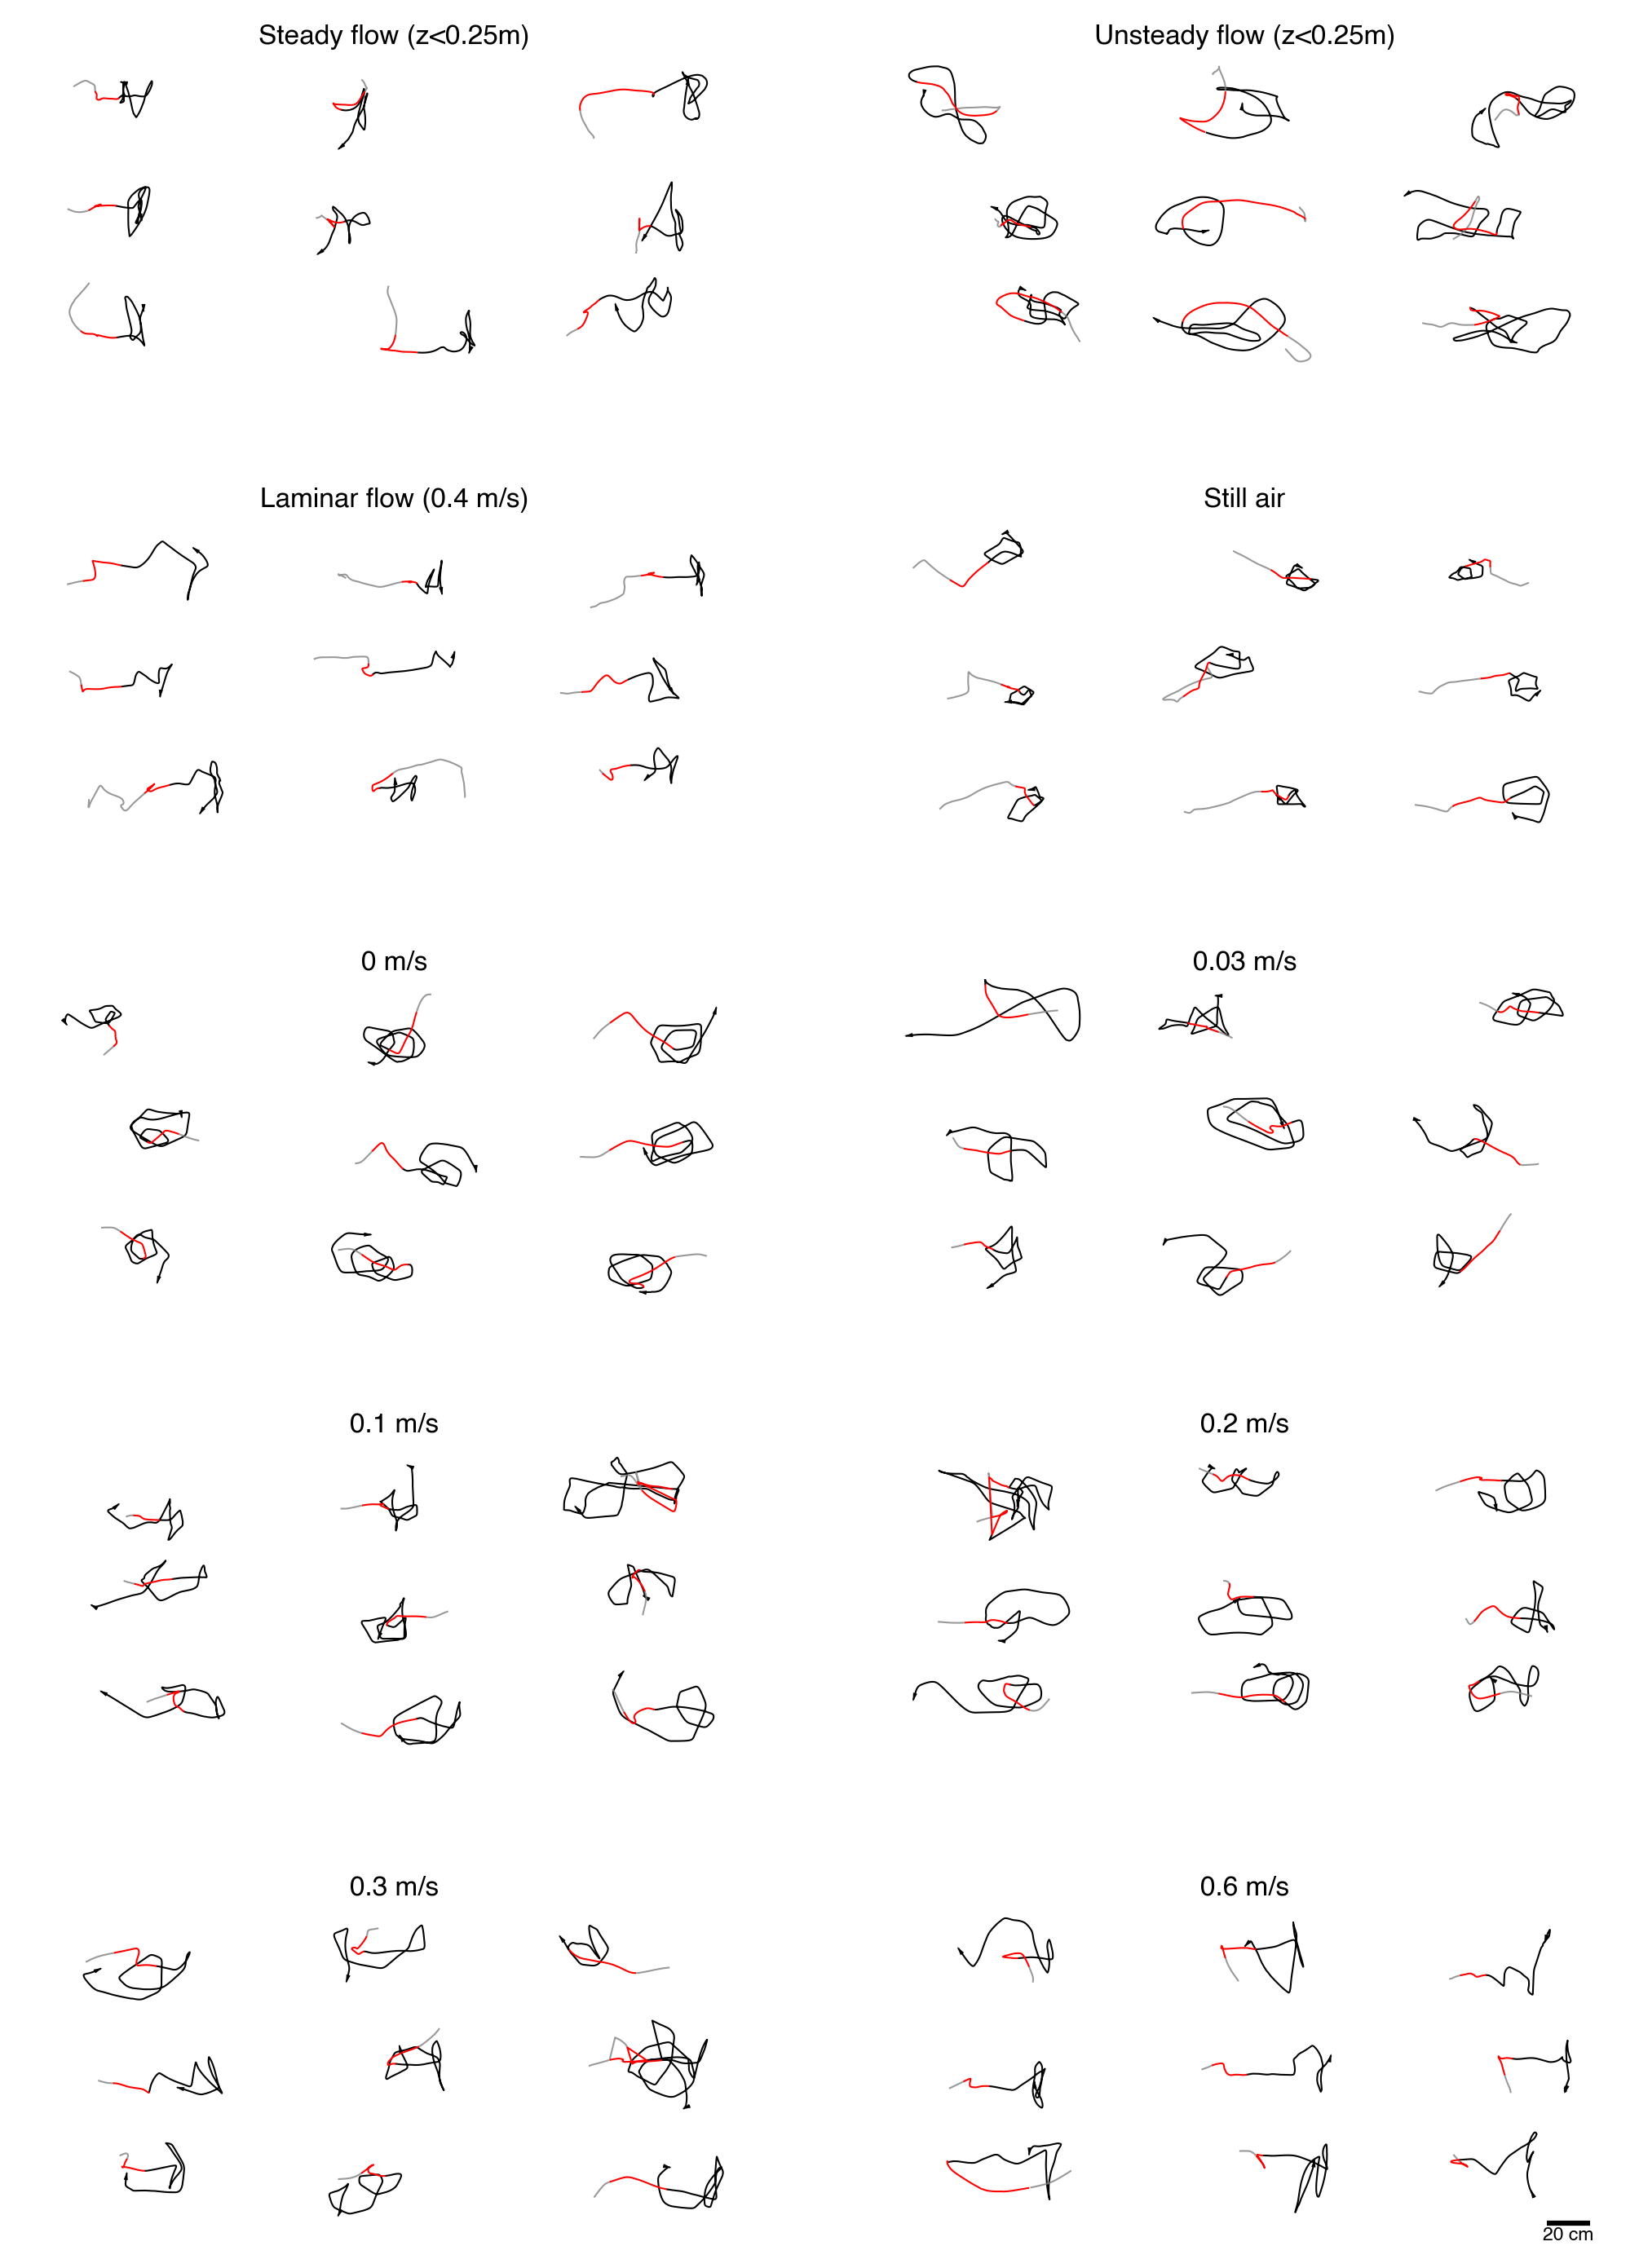

In [163]:
# 10 conditions → 5 rows × 2 cols of condition panels
N_PANEL_ROWS = (len(conditions) + 1) // 2
N_PANEL_COLS = 2

fig = plt.figure(figsize=(8.5, 11))
L, R = 1 / 8.5, 7.5 / 8.5    # 1 in left / right margin
B, T = 1 / 11,  10 / 11       # 1 in bottom / top margin

outer_gs = GridSpec(
    N_PANEL_ROWS, N_PANEL_COLS, figure=fig,
    left=L, right=R, bottom=B, top=T,
    wspace=0.15, hspace=0.32,
)

for i, cond in enumerate(conditions):
    p_row, p_col        = divmod(i, N_PANEL_COLS)
    qualified, traj_ids = sampled[cond["label"]]
    is_last_panel       = (i == len(conditions) - 1)

    inner_gs = GridSpecFromSubplotSpec(
        N_TRAJ_ROWS + 1, N_TRAJ_COLS,
        subplot_spec=outer_gs[p_row, p_col],
        wspace=0.02, hspace=0.02,
        height_ratios=[0.2] + [1] * N_TRAJ_ROWS,
    )

    # Panel title
    ax_t = fig.add_subplot(inner_gs[0, :])
    ax_t.text(0.5, 0.15, cond["label"],
              transform=ax_t.transAxes, ha="center", va="bottom",
              fontsize=8, fontweight="bold")
    ax_t.axis("off")

    # Trajectory subplots
    for j, traj_id in enumerate(traj_ids):
        r  = j // N_TRAJ_COLS + 1    # +1 to skip title row
        c  = j %  N_TRAJ_COLS
        ax = fig.add_subplot(inner_gs[r, c])
        plot_trajectory(
            qualified, traj_id, ax, XLIM, YLIM,
            flash_end_sec=FLASH_END_SEC,
            max_time_sec=MAX_TIME_SEC,
            lw=LW, arrow_length=ARROW_LENGTH,
            scale_bar=(is_last_panel and j == N_TRAJS - 1),
        )
    
# Legend
#legend_handles = [
#    mpatches.Patch(color="grey",  alpha=0.8, label="Pre-stimulus"),
#    mpatches.Patch(color="red",             label=f"Lights on (0 – {FLASH_END_SEC} s)"),
#    mpatches.Patch(color="black",           label="Post-stimulus"),
#]
#fig.legend(handles=legend_handles, loc="lower center", ncol=3,
#           fontsize=7, frameon=False, bbox_to_anchor=(0.5, 0.02))

# Save
OUT_PATH = NB_DIR / "combined_real_trajectories.svg"
fig.savefig(OUT_PATH, format="svg", bbox_inches="tight")
print(f"Saved: {OUT_PATH}")

plt.show()